# Анализ данных и подготовка признаков — Предсказание выкупа заказов

**Задача:** по данным AmoCRM предсказать, выкупит ли клиент заказ наложенным платежом (binary classification: `buyout_flag`).

**Контекст:** интернет-магазин товаров для здоровья отправляет заказы через Почту России и СДЭК наложенным платежом. Часть клиентов не забирает товар — это приводит к расходам на доставку и возврат. Данные: выгрузка из AmoCRM за период март 2025 — март 2026, одна строка = одна сделка.

**Ключевой инсайт:** повторные клиенты (`contact_Число сделок >= 1`) выкупают в 97%+ случаев — для них достаточно модели на одном признаке. Основная сложность — **новые клиенты** (buyout ~32.5%), для которых строится LogReg на ~24 признаках.

Этот ноутбук:
1. Загружает и очищает данные
2. Показывает общий обзор и обосновывает фокус на новых клиентах
3. Переключается на новых клиентов и строит EDA по признакам для обучения
4. Создаёт новые признаки
5. Разделяет данные на train/test/val (60/20/20) и сохраняет для ноутбука обучения

In [1]:
import pandas as pd
import numpy as np
import json
import os
import pickle
import warnings
import calendar
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)

In [2]:
# === Вспомогательные функции визуализации ===
GREEN = '#2ecc71'
RED = '#e74c3c'
LIGHT_GRAY = '#ecf0f1'

LEAD_QUAL_ORDER = ['А - лид', 'В - лид', 'С - лид', 'D/Неквал лид', 'D - лид', 'Е - лид', 'Неквал лид']

CUSTOM_ORDERS = {
    '_deal_group': ['0 (новый)', '1', '2', '3', '4', '5+'],
    'price_bin': ['0-3k', '3-5k', '5-8k', '8-15k', '15-25k', '25k+', 'unknown'],
    'cart_bin': ['1-8', '9-12', '13-16', '17+'],
    'manager_bin': ['0-800', '800-1.8k', '1.8-3k', '3k+'],
    'delta_bin': ['<30мин', '30-60мин', '1-2ч', '>2ч'],
}

def _ordered_categories(col, counts_index, n_tot):
    """Порядок меток: спецпорядок для известных столбцов, иначе по количеству."""
    idx_set = set(counts_index)
    def by_total_desc(keys):
        return sorted(keys, key=lambda x: -int(n_tot.loc[x]))

    if col in CUSTOM_ORDERS:
        return [c for c in CUSTOM_ORDERS[col] if c in idx_set]

    if col == 'sale_weekday':
        nums = sorted([x for x in idx_set if str(x).isdigit()], key=lambda x: int(x))
        rest = [x for x in idx_set if not str(x).isdigit()]
        return nums + by_total_desc(rest)

    if col == 'lead_Квалификация лида':
        order = [q for q in LEAD_QUAL_ORDER if q in idx_set]
        rest = [x for x in idx_set if x not in order]
        return order + by_total_desc(rest)

    return by_total_desc(list(idx_set))


def plot_feature_two_panel(df, col, title, top_n=None):
    """Категориальный признак: верх - count bars, низ - stacked 100% bars."""
    work = df
    if top_n is not None:
        keep = df[col].value_counts().head(top_n).index
        work = df.loc[df[col].isin(keep)]
    g = work.groupby(col, observed=True)['buyout_flag']
    n_buy = g.sum()
    n_tot = g.count()
    n_cancel = n_tot - n_buy
    rate = (n_buy / n_tot.replace(0, np.nan)).fillna(0.0)

    order = _ordered_categories(col, n_buy.index, n_tot)
    n_buy = n_buy.reindex(order, fill_value=0)
    n_cancel = n_cancel.reindex(order, fill_value=0)
    rate = rate.reindex(order, fill_value=0)

    labels = [str(x) for x in order]
    x = np.arange(len(labels))
    w = 0.36

    _fw, _fh = (14, 9) if top_n is not None else (11, 8)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(_fw, _fh), sharex=True)
    fig.suptitle(title, fontsize=13)

    ax1.bar(x - w/2, n_buy.values, width=w, color=GREEN, label='Выкуп (продажи)')
    ax1.bar(x + w/2, n_cancel.values, width=w, color=RED, label='Отмена (без выкупа)')
    ax1.set_ylabel('Количество')
    ax1.legend(loc='center right')
    ax1.grid(axis='y', alpha=0.3, zorder=0)

    # Нижний график: stacked bars. Пустые бины (n_tot=0) оставляем серыми.
    n_tot_vals = (n_buy + n_cancel).values
    for i_bar in range(len(x)):
        if n_tot_vals[i_bar] == 0:
            ax2.bar(x[i_bar], 1.0, color=LIGHT_GRAY, edgecolor='#bdc3c7', linewidth=0.5)
        else:
            ax2.bar(x[i_bar], rate.values[i_bar], color=GREEN)
            ax2.bar(x[i_bar], 1.0 - rate.values[i_bar], bottom=rate.values[i_bar], color=RED)

    ax2.set_ylabel('Доля')
    ax2.set_ylim(0, 1)
    from matplotlib.patches import Patch
    legend_handles = [Patch(color=GREEN, label='Доля выкупа'),
                      Patch(color=RED, label='Доля отмен')]
    if 0 in n_tot_vals:
        legend_handles.append(Patch(color=LIGHT_GRAY, label='Нет данных'))
    ax2.legend(handles=legend_handles, loc='center right')
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels, rotation=45, ha='right')
    ax2.grid(axis='y', alpha=0.3, zorder=0)

    tbl = pd.DataFrame({
        'выкуп': n_buy.astype(int).values,
        'без_выкупа': n_cancel.astype(int).values,
        'всего': (n_buy + n_cancel).astype(int).values,
        'buyout_rate': rate.values,
    }, index=labels)
    tbl.index.name = col
    print(f"\n{'=' * 60}\n{title}\n{'=' * 60}")
    print(tbl.to_string(float_format='%.3f'))

    plt.tight_layout(); plt.show()


def plot_numeric_buyout_by_hist(df, col, title=None, bins=30, xlim=None):
    """Числовой признак: верх - наложенные гистограммы, низ - доля выкупа по бинам."""
    if title is None:
        title = col
    s = pd.to_numeric(df[col], errors='coerce')
    mask = s.notna()
    if not mask.any():
        print(f'\n{col}: нет данных (всё NaN), пропуск\n')
        return
    vals = s[mask].to_numpy(dtype=float)
    buy = df.loc[mask, 'buyout_flag'].astype(bool).to_numpy()

    hist_range = None
    lo_r = hi_r = None
    if xlim is not None:
        lo_r, hi_r = xlim[0], xlim[1]
        if lo_r is None: lo_r = float(np.min(vals))
        if hi_r is None: hi_r = float(np.max(vals))
        win = (vals >= lo_r) & (vals <= hi_r)
        vals_f, buy_f = vals[win], buy[win]
        if vals_f.size == 0:
            print(f'\n{col}: нет точек в xlim, пропуск\n')
            return
        hist_range = (lo_r, hi_r)
    else:
        vals_f, buy_f = vals, buy

    _, edges = np.histogram(vals_f, bins=bins, range=hist_range) if hist_range else np.histogram(vals_f, bins=bins)
    nbins = len(edges) - 1
    idx = np.clip(np.searchsorted(edges, vals_f, side='right') - 1, 0, nbins - 1)

    n_tot = np.bincount(idx, minlength=nbins)[:nbins].astype(int)
    n_buy_arr = np.bincount(idx[buy_f], minlength=nbins)[:nbins].astype(int)
    n_cancel_arr = n_tot - n_buy_arr
    rate = np.divide(n_buy_arr.astype(float), n_tot, out=np.full(nbins, np.nan), where=n_tot > 0)

    left = edges[:-1]
    widths = np.diff(edges)
    mean_v = float(np.mean(vals_f))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True,
                                    gridspec_kw={'height_ratios': [1, 1.25]})
    fig.suptitle(f'{title} (bins={nbins})', fontsize=13)

    ax1.hist(vals_f[buy_f], bins=edges, color=GREEN, alpha=0.55,
             label='Выкуп (продажи)', edgecolor='none')
    ax1.hist(vals_f[~buy_f], bins=edges, color=RED, alpha=0.55,
             label='Отмена (без выкупа)', edgecolor='none')
    ax1.axvline(mean_v, color='black', linestyle='--', linewidth=1, label='Среднее', zorder=5)
    ax1.set_ylabel('Количество')
    ax1.legend(loc='upper right')
    ax1.grid(axis='y', alpha=0.3)

    # Нижний график: доля выкупа. Пустые бины оставляем белыми.
    for i_bar in range(nbins):
        if n_tot[i_bar] == 0:
            continue  # пустой бин - не рисуем ничего
        ax2.bar(left[i_bar], rate[i_bar], width=widths[i_bar], align='edge',
                color=GREEN, edgecolor='none', linewidth=0)
        ax2.bar(left[i_bar], 1.0 - rate[i_bar], width=widths[i_bar],
                bottom=rate[i_bar], align='edge', color=RED, edgecolor='none', linewidth=0)

    ax2.set_ylabel('Доля')
    ax2.set_xlabel(col)
    ax2.set_ylim(0, 1)
    from matplotlib.patches import Patch
    ax2.legend(handles=[Patch(color=GREEN, label='Доля выкупа'),
                        Patch(color=RED, label='Доля отмен')], loc='upper right')
    ax2.grid(axis='y', alpha=0.3)
    ax2.axvline(mean_v, color='black', linestyle='--', linewidth=1, zorder=5)

    if hist_range is not None:
        ax2.set_xlim(lo_r, hi_r)

    bin_lbl = [f'[{left[i]:.4g}, {edges[i+1]:.4g}]' for i in range(nbins)]
    tbl = pd.DataFrame({'выкуп': n_buy_arr, 'без_выкупа': n_cancel_arr, 'всего': n_tot}, index=bin_lbl)
    tbl.index.name = col
    print(f"\n{'=' * 60}\n{title}\n{'=' * 60}")
    print(tbl.to_string())

    plt.tight_layout(); plt.show()

print('Функции визуализации определены')

Функции визуализации определены


## 1. Загрузка и очистка данных

Датасет содержит записи о заказах из AmoCRM за период март 2025 — март 2026. Каждая строка — одна сделка (lead) с информацией о клиенте, товаре, доставке и статусе.

Очистка:
- Убираем строки с `outcome_unknown == True` — сделки, по которым исход ещё неизвестен
- Приводим `buyout_flag` к бинарному формату (0/1)
- Конвертируем типы столбцов (даты, числа)

In [3]:
DATA_PATH = 'dataset_2025-03-01_2026-03-29_external.csv'
if not os.path.exists(DATA_PATH):
    DATA_PATH = '../dataset_2025-03-01_2026-03-29_external.csv'

df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Загружено строк: {len(df_raw)}")

# Убираем строки с неизвестным исходом
df = df_raw[df_raw['outcome_unknown'] == False].copy()
print(f"С известным исходом: {len(df)}")

# Целевая переменная
df['buyout_flag'] = df['buyout_flag'].map(
    {'True': 1, 'true': 1, True: 1, 'False': 0, 'false': 0, False: 0}
).astype(int)

# Приведение типов
df['sale_ts'] = pd.to_numeric(df['sale_ts'], errors='coerce')
df['lead_created_at'] = pd.to_numeric(df['lead_created_at'], errors='coerce')
df['sale_date'] = pd.to_datetime(df['sale_date'], errors='coerce')
df['lead_price'] = pd.to_numeric(df['lead_price'], errors='coerce')
df['contact_Число сделок'] = pd.to_numeric(df.get('contact_Число сделок'), errors='coerce')

for col in ['lead_Вес (грамм)*', 'lead_Длина', 'lead_Ширина', 'lead_Высота',
             'lead_Скидка', 'lead_Стоимость доставки', 'lead_Масса (гр)']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

buyout_rate = df['buyout_flag'].mean()
print(f"\nBuyout rate: {buyout_rate:.4f} ({buyout_rate*100:.1f}%)")
print(f"Выкуп: {df['buyout_flag'].sum()}, Отказ: {(1 - df['buyout_flag']).sum():.0f}")

Загружено строк: 18887
С известным исходом: 17966

Buyout rate: 0.8283 (82.8%)
Выкуп: 14882, Отказ: 3084


## 2. Общий обзор данных

Прежде чем строить модель, посмотрим на общую картину: распределение целевой переменной и buyout rate для двух ключевых групп клиентов — новых и повторных.

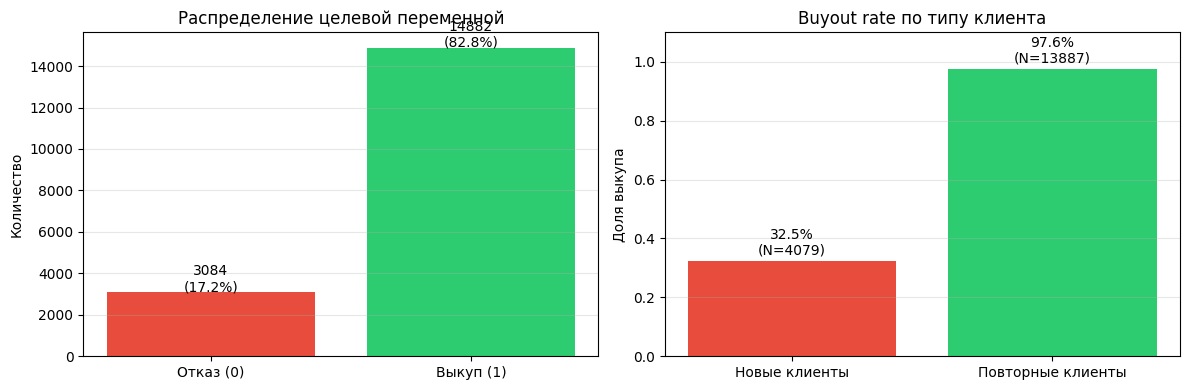

Всего строк: 17966
Новые клиенты: 4079 (22.7%), buyout: 0.3248
Повторные:     13887 (77.3%), buyout: 0.9762


In [4]:
# Баланс классов
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['buyout_flag'].value_counts().sort_index()
axes[0].bar(['Отказ (0)', 'Выкуп (1)'], counts.values, color=[RED, GREEN])
axes[0].set_title('Распределение целевой переменной')
axes[0].set_ylabel('Количество')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v}\n({v/len(df)*100:.1f}%)', ha='center')
axes[0].grid(axis='y', alpha=0.3)

# Новые vs повторные
is_new = df['contact_Число сделок'].isna() | (df['contact_Число сделок'] < 1)
groups = pd.DataFrame({
    'type': ['Новые клиенты', 'Повторные клиенты'],
    'count': [is_new.sum(), (~is_new).sum()],
    'buyout_rate': [df.loc[is_new, 'buyout_flag'].mean(), df.loc[~is_new, 'buyout_flag'].mean()]
})

bars = axes[1].bar(groups['type'], groups['buyout_rate'], color=[RED, GREEN])
axes[1].set_title('Buyout rate по типу клиента')
axes[1].set_ylabel('Доля выкупа')
axes[1].set_ylim(0, 1.1)
for bar, rate, cnt in zip(bars, groups['buyout_rate'], groups['count']):
    axes[1].text(bar.get_x() + bar.get_width()/2, rate + 0.02,
                 f'{rate:.1%}\n(N={cnt})', ha='center')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

print(f"Всего строк: {len(df)}")
print(f"Новые клиенты: {is_new.sum()} ({is_new.mean()*100:.1f}%), buyout: {df.loc[is_new, 'buyout_flag'].mean():.4f}")
print(f"Повторные:     {(~is_new).sum()} ({(~is_new).mean()*100:.1f}%), buyout: {df.loc[~is_new, 'buyout_flag'].mean():.4f}")

### Ключевой инсайт: два типа клиентов

Данные показывают радикальное различие между двумя группами:
- **Повторные клиенты** (77% заказов) — buyout 97%+. Клиент, заказывавший ранее, почти гарантированно выкупит снова. Предсказание тривиально: одного признака `contact_Число сделок` достаточно.
- **Новые клиенты** (23% заказов) — buyout ~32.5%. Именно здесь бизнес теряет деньги на доставке невыкупленных заказов, и именно здесь ML-модель принесёт наибольшую пользу.

Чтобы убедиться в этом визуально, построим buyout rate в разбивке по количеству прошлых заказов клиента:


Buyout rate по числу прошлых заказов клиента
             выкуп  без_выкупа  всего  buyout_rate
_deal_group                                       
0 (новый)     1325        2754   4079        0.325
1             9963         233  10196        0.977
2             1855          63   1918        0.967
3              627          18    645        0.972
4              368           4    372        0.989
5+             744          12    756        0.984


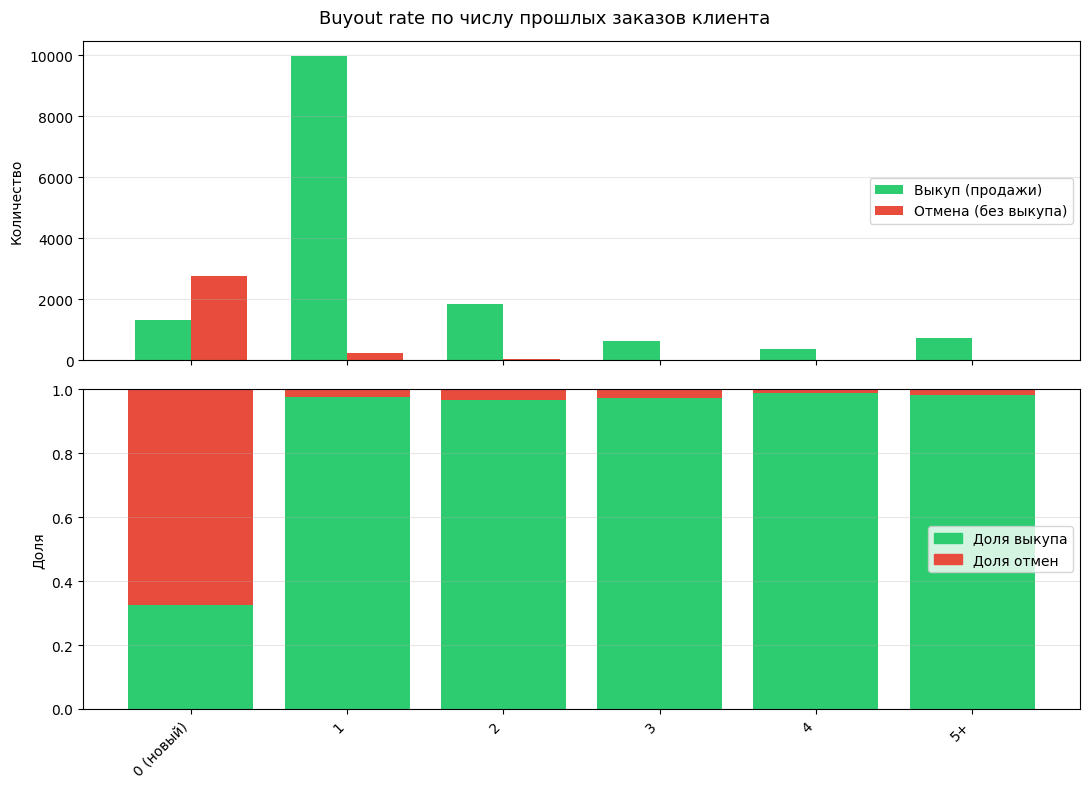

In [5]:
# Группируем по числу прошлых сделок
deal_counts = df['contact_Число сделок'].fillna(0).astype(int)
deal_counts = deal_counts.clip(upper=5)
df['_deal_group'] = deal_counts.astype(str)
df.loc[df['_deal_group'] == '5', '_deal_group'] = '5+'
df.loc[df['_deal_group'] == '0', '_deal_group'] = '0 (новый)'

plot_feature_two_panel(df, '_deal_group', 'Buyout rate по числу прошлых заказов клиента')

df.drop(columns=['_deal_group'], inplace=True)

## 3. Фокус на новых клиентах

График выше наглядно демонстрирует: начиная с 1-го прошлого заказа buyout rate >96%. Анализировать и моделировать повторных клиентов нет смысла — для них достаточно простой модели на одном признаке.

**С этого момента весь дальнейший анализ проводится только на новых клиентах** — записях, где `contact_Число сделок` = NaN или 0. Именно для этого сегмента строится основная ML-модель.

In [6]:
# Сохраняем полный датасет для финального разделения
df_full = df.copy()

# Переключаемся на новых клиентов
is_new = df['contact_Число сделок'].isna() | (df['contact_Число сделок'] < 1)
df = df[is_new].copy()

print(f'Новые клиенты: {len(df)}')
print(f'Buyout rate: {df["buyout_flag"].mean():.4f} ({df["buyout_flag"].mean()*100:.1f}%)')
print(f'Выкуп: {df["buyout_flag"].sum()}, Отказ: {(1 - df["buyout_flag"]).sum():.0f}')

Новые клиенты: 4079
Buyout rate: 0.3248 (32.5%)
Выкуп: 1325, Отказ: 2754


## 4. EDA — Категориальные признаки (новые клиенты)

Для каждого категориального признака, который будет использоваться в модели, строим двухпанельный график:
- **Верх:** количество выкупов и отказов по категориям (side-by-side bars)
- **Низ:** доля выкупа в каждой категории (stacked 100% bars)

Важно: для ряда признаков **NaN — это информативный класс**, а не пропуск. NaN в `lead_Квалификация лида`, `lead_Категория и варианты выбора`, `lead_Модель телефона` и `lead_будущие покупки` означает, что менеджер не звонил клиенту.

In [7]:
# NaN -> '__NaN__' для всех категориальных признаков
# Для первой группы (38-56% NaN) NaN несёт информацию: менеджер не звонил клиенту,
# часто это заказы через Почту с высоким buyout.
# Для второй группы (0.2-0.3% NaN) NaN = редкие пропуски данных.
# Модель обрабатывает оба случая одинаково - как отдельную категорию.
for col in ['lead_Квалификация лида', 'lead_Категория и варианты выбора',
            'lead_Тариф Доставки', 'lead_будущие покупки', 'lead_Модель телефона',
            'lead_Служба доставки', 'lead_Вид оплаты', 'lead_Проблема']:
    if col in df.columns:
        df[col] = df[col].fillna('__NaN__')

# Объединение мелких категорий
# Квалификация лида: Неквал лид (39 шт) + D-лид (11 шт) -> D/Неквал лид
mask = df['lead_Квалификация лида'].isin(['Неквал лид', 'D - лид'])
df.loc[mask, 'lead_Квалификация лида'] = 'D/Неквал лид'

# Категория и варианты выбора: Нет категории (40 шт) -> объединяем с __NaN__
mask = df['lead_Категория и варианты выбора'] == 'Нет категории'
df.loc[mask, 'lead_Категория и варианты выбора'] = '__NaN__'

print('NaN-обработка и объединение мелких категорий завершены')
print(f'Строк: {len(df)}')

NaN-обработка и объединение мелких категорий завершены
Строк: 4079



lead_Служба доставки
                      выкуп  без_выкупа  всего  buyout_rate
lead_Служба доставки                                       
СДЭК до ПВЗ             230        1707   1937        0.119
Почта                  1047         652   1699        0.616
СДЭК до Двери            40         383    423        0.095
Самовывоз                 7           2      9        0.778
__NaN__                   0           9      9        0.000
Курьер ЕМС                1           1      2        0.500


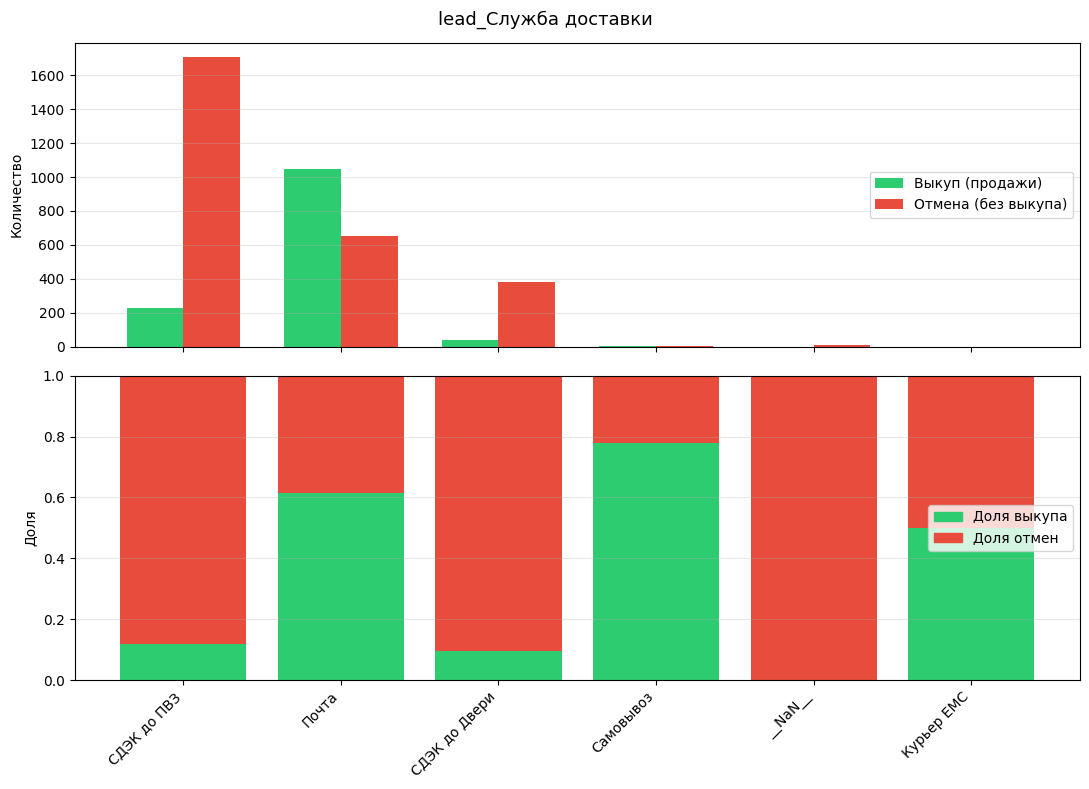


lead_Тариф Доставки
                                 выкуп  без_выкупа  всего  buyout_rate
lead_Тариф Доставки                                                   
Посылка склад-склад                541        1854   2395        0.226
Почта Посылка                      562         384    946        0.594
Посылка склад-дверь                 44         374    418        0.105
__NaN__                            159          96    255        0.624
Экономичная посылка склад-склад      2          25     27        0.074
Почта Посылка 1 класса              12          11     23        0.522
Экономичная посылка склад-дверь      2           8     10        0.200
Экспресс склад-склад                 1           1      2        0.500
Экспресс склад-дверь                 1           1      2        0.500
Посылка склад-постамат               1           0      1        1.000


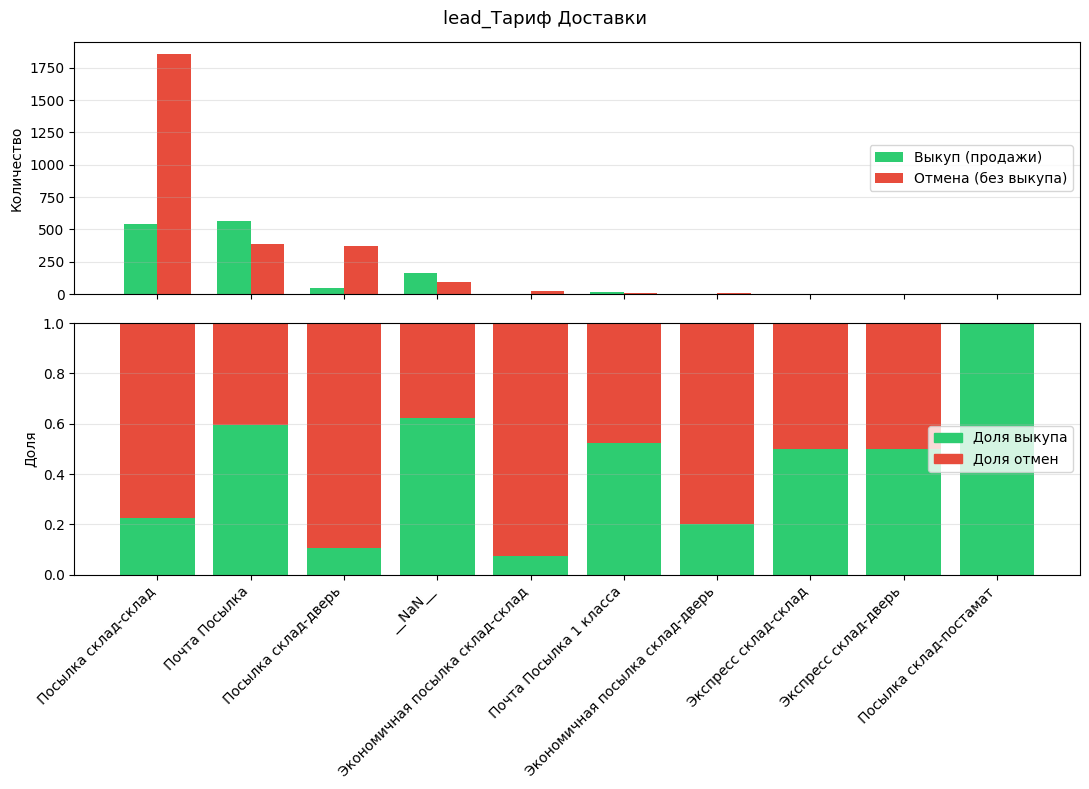


lead_Квалификация лида
                        выкуп  без_выкупа  всего  buyout_rate
lead_Квалификация лида                                       
А - лид                   267         887   1154        0.231
В - лид                   142         647    789        0.180
С - лид                    95         411    506        0.188
D/Неквал лид               16          34     50        0.320
__NaN__                   805         775   1580        0.509


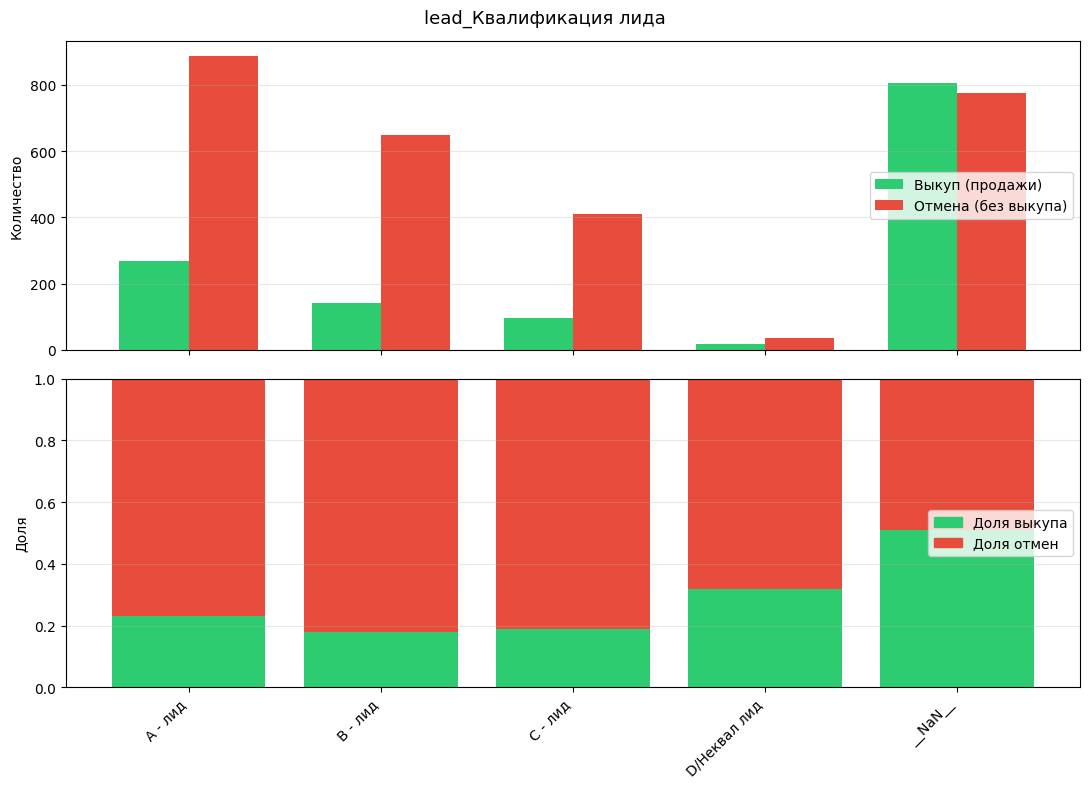


lead_Категория и варианты выбора
                                  выкуп  без_выкупа  всего  buyout_rate
lead_Категория и варианты выбора                                       
__NaN__                            1115        1213   2328        0.479
S                                   111         850    961        0.116
I                                    48         431    479        0.100
D                                    40         198    238        0.168
C                                    11          62     73        0.151


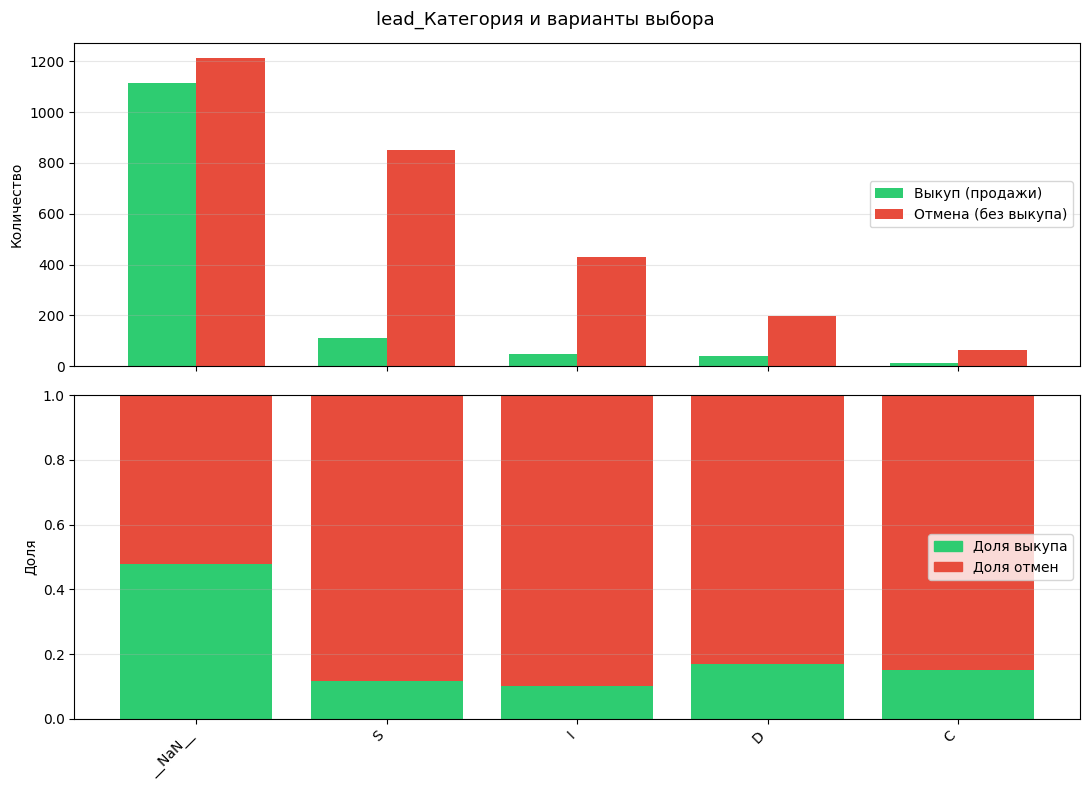


lead_Модель телефона
                      выкуп  без_выкупа  всего  buyout_rate
lead_Модель телефона                                       
Смартфон                415        1198   1613        0.257
__NaN__                 617         577   1194        0.517
Не удалось узнать       264         923   1187        0.222
Кнопочный                29          56     85        0.341


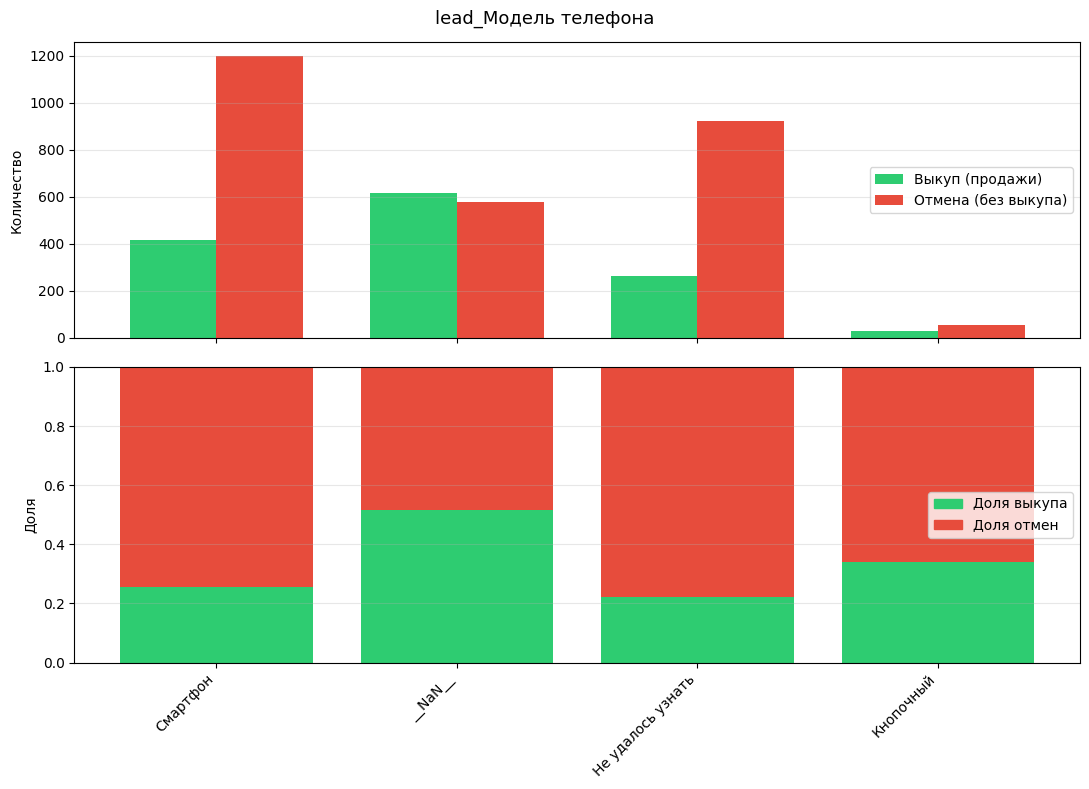


lead_Вид оплаты
                        выкуп  без_выкупа  всего  buyout_rate
lead_Вид оплаты                                              
Наложенный платеж        1287        2728   4015        0.321
Оплата онлайн              23          11     34        0.676
Оплата на карту            13           4     17        0.765
__NaN__                     2          10     12        0.167
Оплата Золотой Короной      0           1      1        0.000


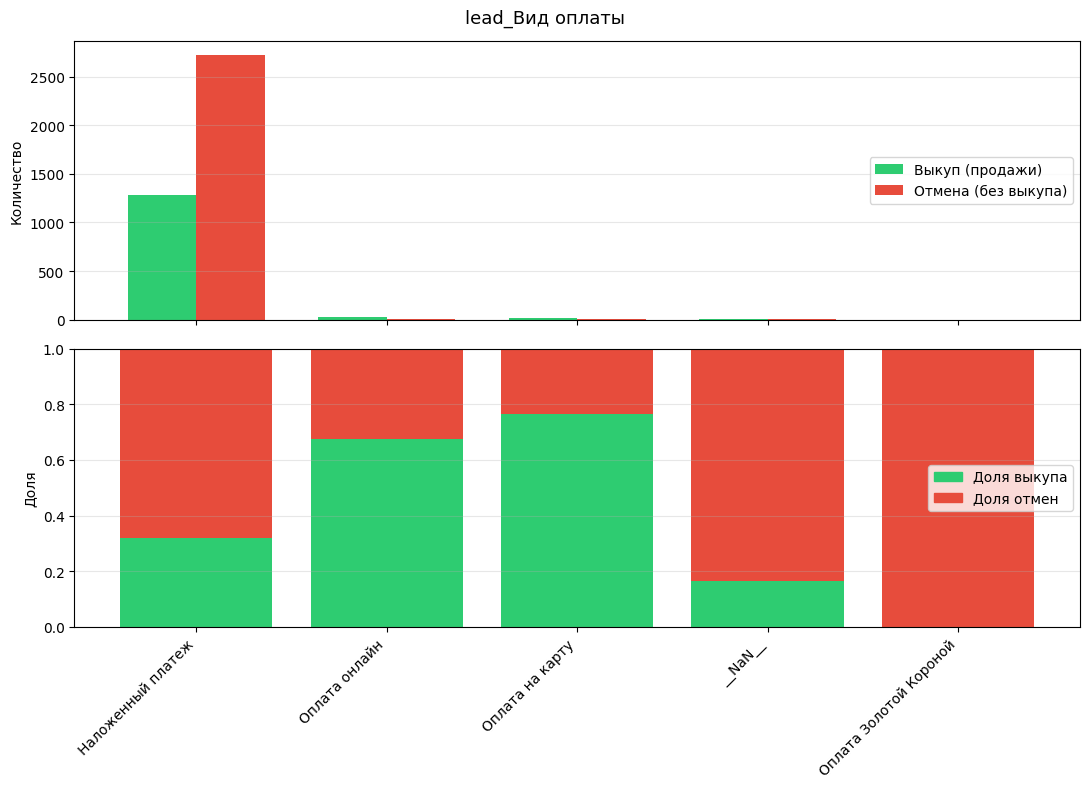


lead_pipeline_id
                  выкуп  без_выкупа  всего  buyout_rate
lead_pipeline_id                                       
6892026            1320        2670   3990        0.331
6892030               1          73     74        0.014
8182978               0          11     11        0.000
9222114               4           0      4        1.000


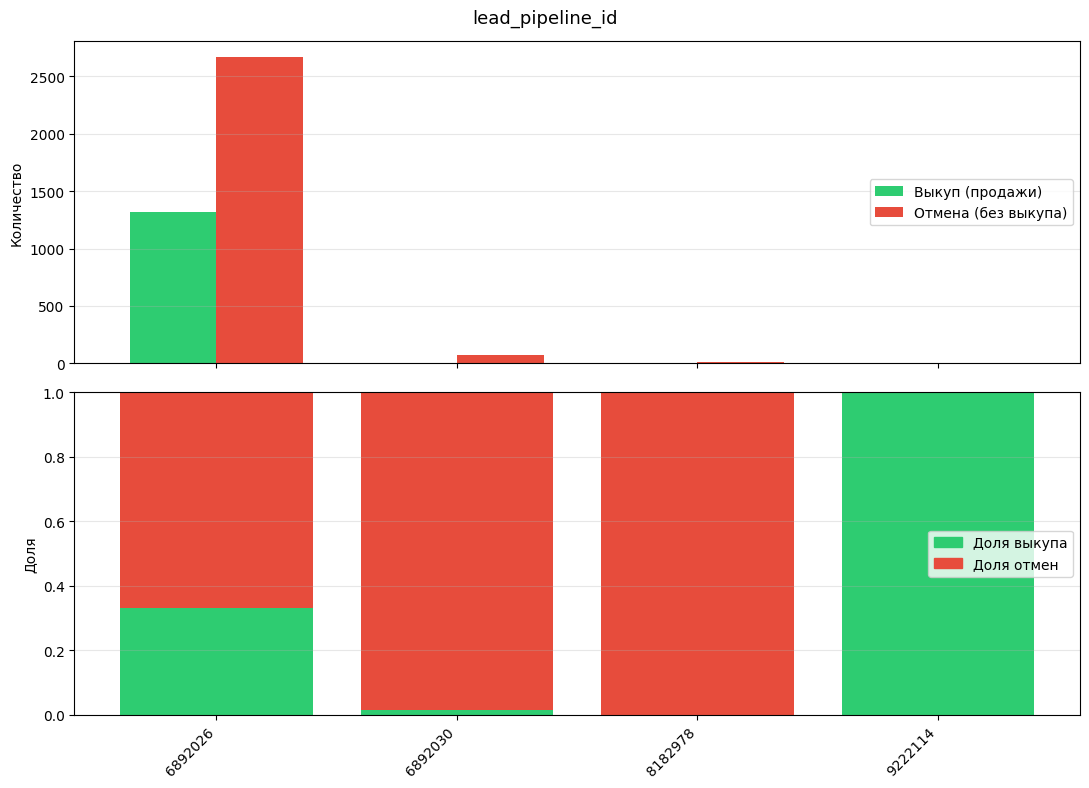


lead_будущие покупки
                      выкуп  без_выкупа  всего  buyout_rate
lead_будущие покупки                                       
не известно             330        1423   1753        0.188
__NaN__                 805         776   1581        0.509
унив повязка             80         208    288        0.278
матрас                   44         144    188        0.234
подушка                  43         131    174        0.247
сапоги                    6          22     28        0.214
шлем                      5          14     19        0.263
одеяло                    3          13     16        0.188
жилет                     3          10     13        0.231
шорты                     5           6     11        0.455
капсула                   1           7      8        0.125


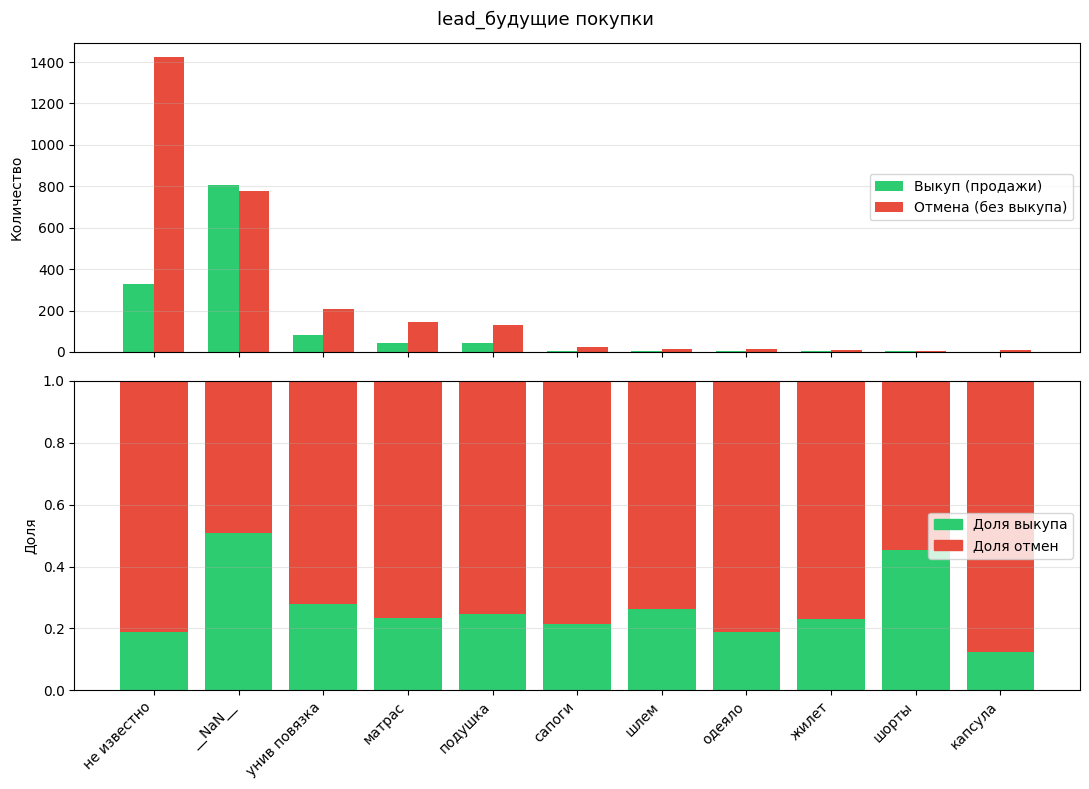


lead_Проблема
                                 выкуп  без_выкупа  всего  buyout_rate
lead_Проблема                                                         
Суставы и позвоночник              551        1132   1683        0.327
Варикоз                            421         909   1330        0.317
Сердечно-сосудистые заболевания     80         186    266        0.301
Бессоница                          102         141    243        0.420
Головные боли                       56          76    132        0.424
Зрительная система                  54          42     96        0.562
Отеки                                8          80     88        0.091
Инсульт                             12          45     57        0.211
Давление                             4          50     54        0.074
Боли и тяжесть в ногах              10          35     45        0.222
Ушибы. травмы, отеки, ожоги          4          12     16        0.250
__NaN__                              1          12     13     

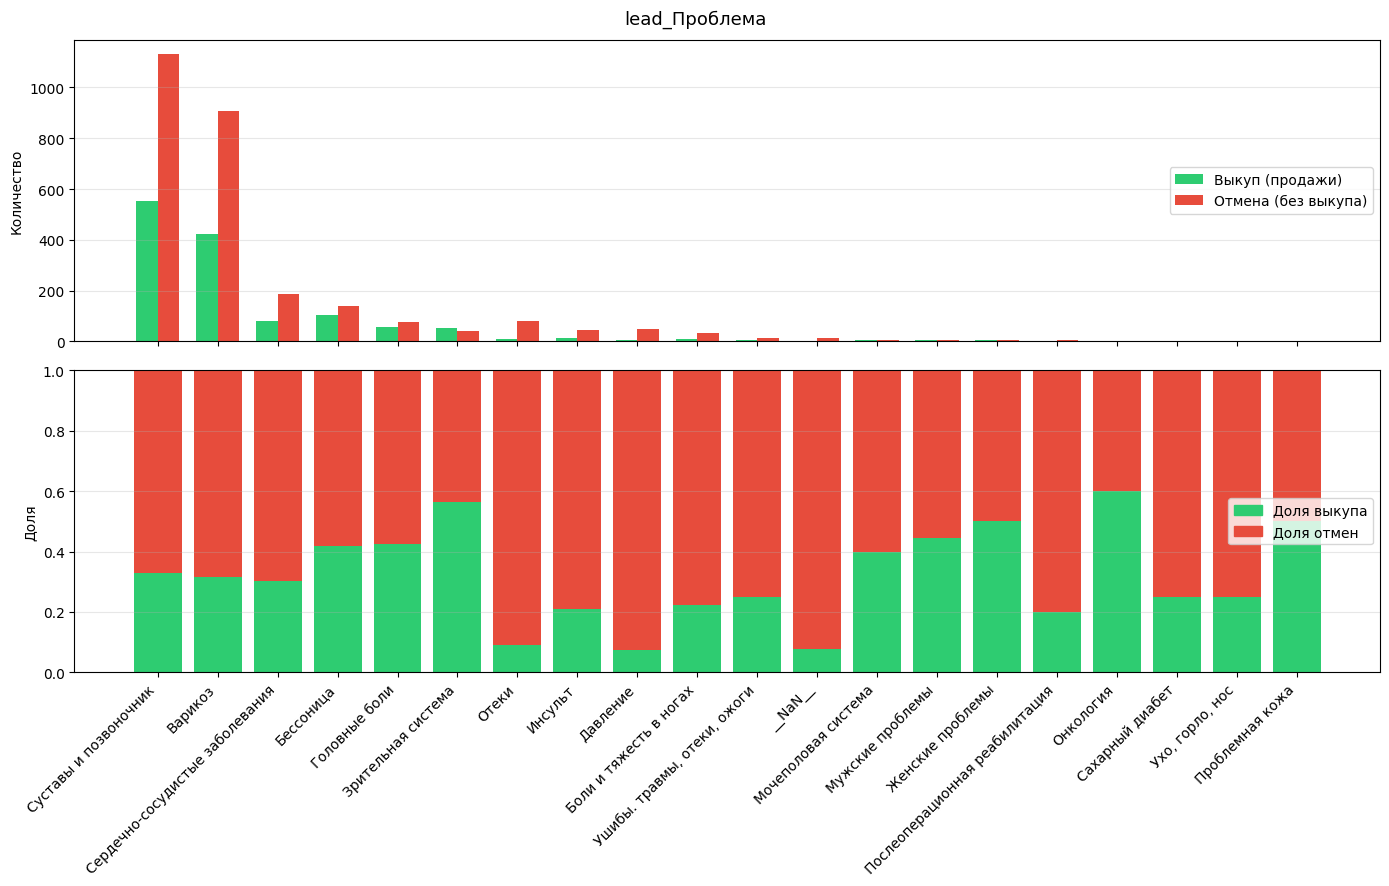

In [8]:
# Категориальные признаки для EDA (только те, что пойдут в модель)
CAT_EDA = [
    'lead_Служба доставки',                  # сильнейший предиктор, 50+ п.п.
    'lead_Тариф Доставки',                   # 55 п.п., коррелирует со Службой
    'lead_Квалификация лида',                # 42 п.п., NaN = лучший класс
    'lead_Категория и варианты выбора',      # 38 п.п., DISC-профиль
    'lead_Модель телефона',                  # 30 п.п.
    'lead_Вид оплаты',                       # 60 п.п., но 98% — одна категория
    'lead_pipeline_id',                       # слабый, но бесплатный
    'lead_будущие покупки',                  # 32 п.п.
    'lead_Проблема',                         # 49 п.п., 24 тематики
]

for col in CAT_EDA:
    if col not in df.columns:
        print(f'{col}: отсутствует в данных, пропуск')
        continue
    n_unique = df[col].nunique()
    top_n = 20 if n_unique > 20 else None
    plot_feature_two_panel(df, col, col, top_n=top_n)

### Наблюдения по категориальным признакам (новые клиенты)

- **`lead_Служба доставки`** — самый сильный категориальный предиктор. Почта: buyout 61.6% (1699 заказов), СДЭК до ПВЗ: 11.9% (1937), СДЭК до Двери: 9.5% (423). Разрыв между Почтой и СДЭК — более 50 п.п.
- **`lead_Тариф Доставки`** — детализирует службу доставки. Почта Посылка: 59.4%, Посылка склад-склад: 22.6%, Посылка склад-дверь: 10.5%. NaN (6.3% записей) имеет buyout 62.4% — информативная категория.
- **`lead_Квалификация лида`** — NaN (38.7%) = buyout 50.9%; A-лид: 23.1%, B-лид: 18.0%, C-лид: 18.8%. NaN (менеджер не заполнил квалификацию) = лучший предиктор выкупа. Вероятная причина: это заказы через Почту, где клиент сам оформил заказ без участия менеджера.
- **`lead_Категория и варианты выбора`** — DISC-профиль клиента. NaN (56.1%) = buyout 48.1%; S: 11.6%, I: 10.0%, D: 16.8%. NaN означает, что менеджер не проводил типирование клиента.
- **`lead_Модель телефона`** — NaN (29.3%) = buyout 51.7%; Смартфон: 25.7%, Кнопочный: 34.1%, Не удалось узнать: 22.2%. NaN = модель телефона не определяли.
- **`lead_Вид оплаты`** — предоплата (онлайн/карта) = buyout 68-77%, но это лишь 1.3% заказов. 98.4% оплачивают наложенным платежом (32.1%).
- **`lead_Проблема`** — тематика заказа. Разброс buyout от 7.4% (Давление) до 56.3% (Зрительная система). 24 категории.
- **`lead_pipeline_id`** — основная воронка содержит 97.8% заказов. Остальные воронки имеют другой buyout rate, но малочисленны.
- **`lead_будущие покупки`** — NaN (38.8%) = buyout 50.9%; конкретные товары: 19-45%. NaN = менеджер не спрашивал.

## 5. EDA — Числовые признаки (новые клиенты)

Для числовых признаков строим:
- **Верх:** наложенные гистограммы выкупов и отказов
- **Низ:** доля выкупа в каждом бине (stacked 100% bars)


lead_price
                        выкуп  без_выкупа  всего
lead_price                                      
[0, 1333]                  14          28     42
[1333, 2667]               26          26     52
[2667, 4000]              204         204    408
[4000, 5333]               54         114    168
[5333, 6667]              119         195    314
[6667, 8000]              319         397    716
[8000, 9333]               58         390    448
[9333, 1.067e+04]          95         192    287
[1.067e+04, 1.2e+04]       61          94    155
[1.2e+04, 1.333e+04]      107         192    299
[1.333e+04, 1.467e+04]     63         189    252
[1.467e+04, 1.6e+04]       38         127    165
[1.6e+04, 1.733e+04]       48         153    201
[1.733e+04, 1.867e+04]     21         133    154
[1.867e+04, 2e+04]         19          69     88
[2e+04, 2.133e+04]         17          49     66
[2.133e+04, 2.267e+04]      9          44     53
[2.267e+04, 2.4e+04]        8          29     37
[2.4e+04

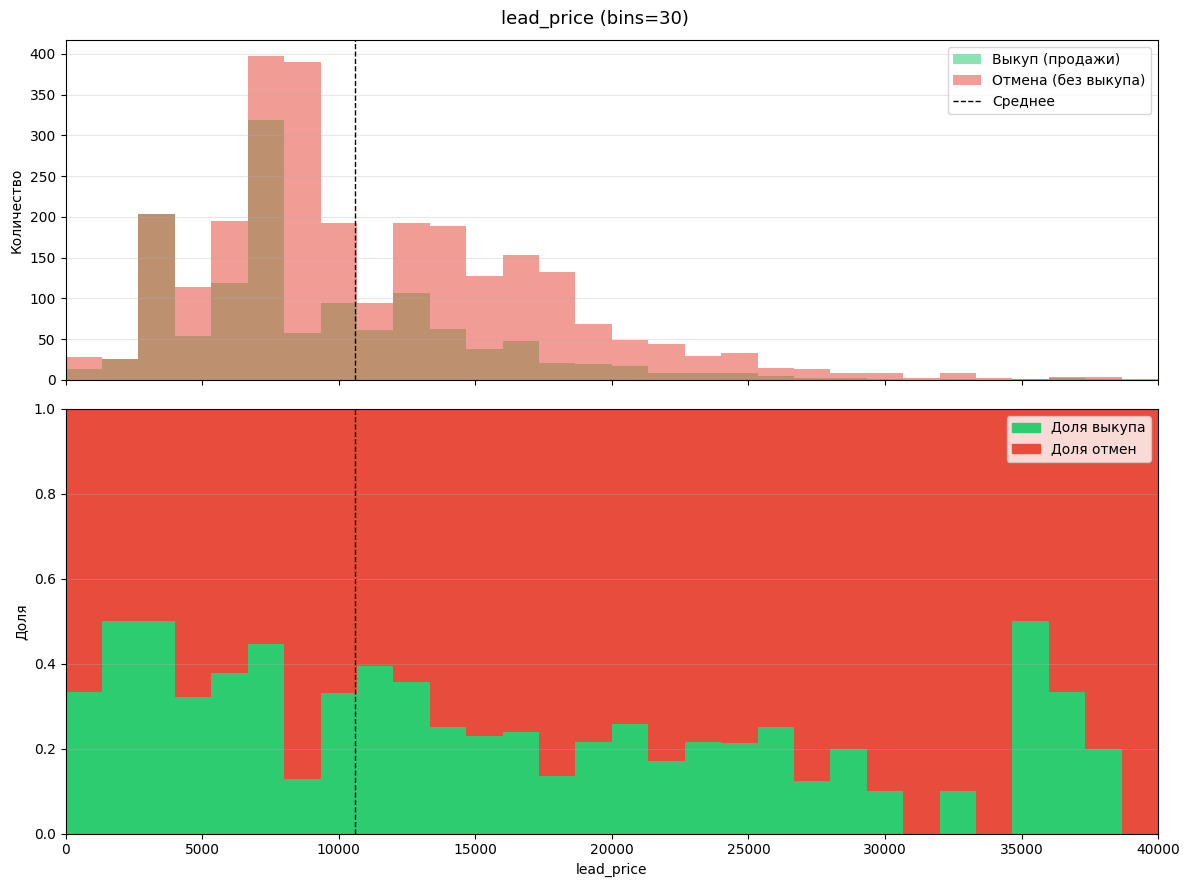


lead_Стоимость доставки
                         выкуп  без_выкупа  всего
lead_Стоимость доставки                          
[381, 431.3]                 1           2      3
[431.3, 481.6]               0           1      1
[481.6, 531.9]               1           0      1
[531.9, 582.2]               0           0      0
[582.2, 632.5]               0           1      1
[632.5, 682.8]               0           0      0
[682.8, 733.1]               2           0      2
[733.1, 783.4]               0           0      0
[783.4, 833.7]               0           0      0
[833.7, 884]                 2           0      2
[884, 934.3]                 0           0      0
[934.3, 984.6]               2           0      2
[984.6, 1035]                0           0      0
[1035, 1085]                 1           0      1
[1085, 1136]                 0           0      0
[1136, 1186]                 2           0      2
[1186, 1236]                 0           0      0
[1236, 1286]             

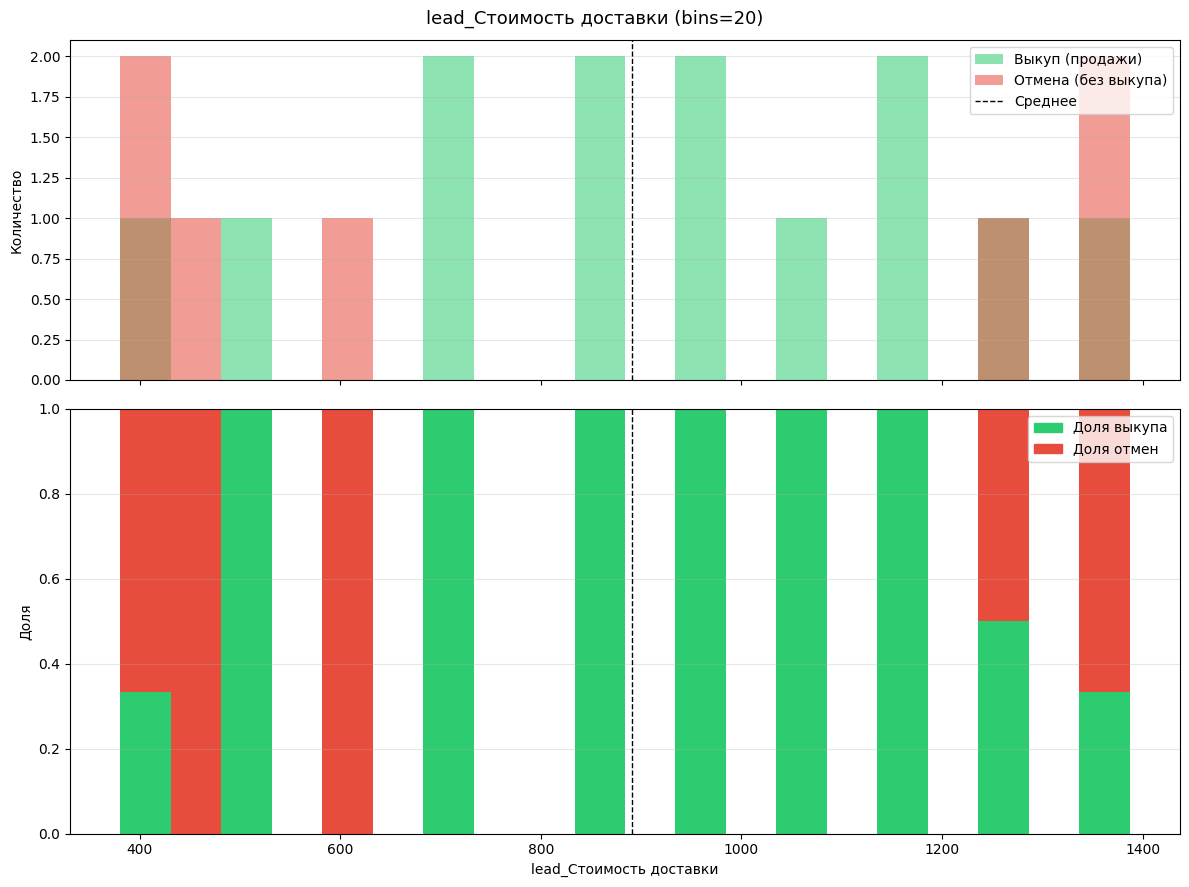


lead_Скидка
             выкуп  без_выкупа  всего
lead_Скидка                          
[0, 5]           1           4      5
[5, 10]          9          10     19
[10, 15]        45         254    299
[15, 20]        35          43     78
[20, 25]         3          16     19
[25, 30]         2          13     15
[30, 35]         1           8      9
[35, 40]         0           0      0


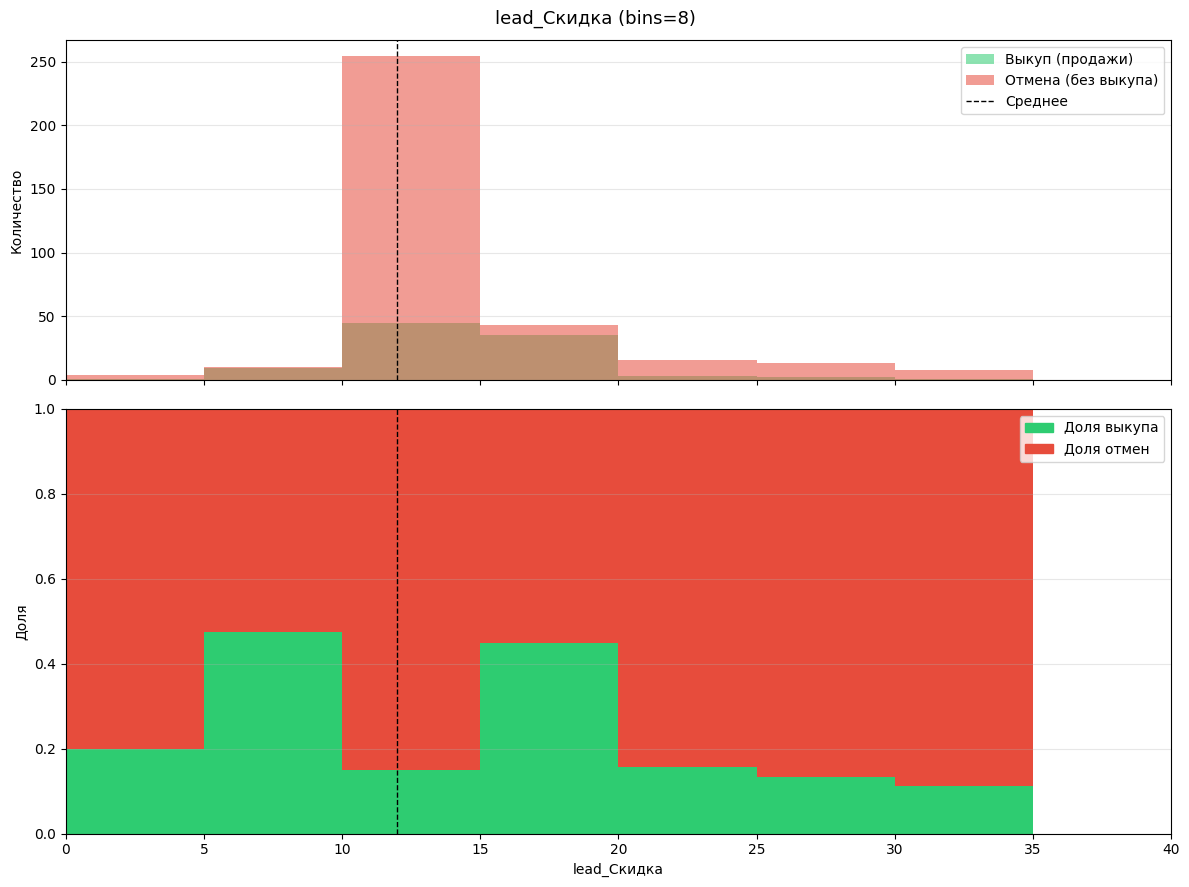

In [9]:
NUM_EDA = {
    'lead_price':              {'bins': 30, 'xlim': (0, 40_000)},
    'lead_Стоимость доставки': {'bins': 20, 'xlim': None},
    'lead_Скидка':             {'bins': 8,  'xlim': (0, 40)},
}

for col, params in NUM_EDA.items():
    if col not in df.columns:
        print(f'{col}: отсутствует, пропуск')
        continue
    plot_numeric_buyout_by_hist(df, col, **params)

### Наблюдения по числовым признакам

- **`lead_price`** — цена заказа. Buyout монотонно убывает с ростом цены: 0-3k = 46.4%, 5-8k = 41.4%, 15-25k = 21.3%. Зависимость нелинейная, поэтому дополнительно создадим `price_bin` (категориальный бин по цене).
- **`lead_Стоимость доставки`** — 60% NaN. Заполненные значения: buyout ~64%, NaN: ~12%. Стоимость доставки заполняется при подготовке заказа к отправке. Различие NaN/заполнено несёт сильный сигнал.
- **`lead_Скидка`** — 89% NaN. Наличие скидки снижает buyout: NaN = 33.8%, заполнено = 21.6% (разница 12 п.п.). Скидка даётся клиентам, которые колеблются с решением о покупке. Числовое значение скидки (5-30%) не показывает устойчивой зависимости с buyout из-за малого числа наблюдений (264 записи).

## 6. Feature Engineering

Создаём признаки для модели новых клиентов:

| Признак | Источник | Тип | Описание |
|---------|----------|-----|----------|
| `cart_bin` | `lead_Состав заказа` | cat | Число товаров в заказе (4 бина: 1-8, 9-12, 13-16, 17+) |
| `price_bin` | `lead_price` | cat | Ценовая группа (6 бинов) |
| `sale_weekday` | `sale_date` | cat | День недели продажи |
| `delta_bin` | `sale_ts - lead_created_at` | cat | Время от заявки до продажи (4 бина: <30мин, 30-60мин, 1-2ч, >2ч) |
| `is_paid_traffic` | `lead_utm_medium` | bin | Платный трафик |
| `has_discount` | `lead_Скидка` | bin | Скидка применена |
| `manager_bin` | `lead_responsible_user_id` | cat | Опытность менеджера (4 бина по числу сделок: 0-800, 800-1.8k, 1.8-3k, 3k+) |
| `city_clean`, `contact_region` | `contact_Город` | geo | Стандартизированный город и регион |

**Решения по форме признаков:**

- **`cart_bin` вместо числа:** распределение `cart_n_items` имеет 4 кластера (7, 11, 15, 19 товаров). Buyout монотонно убывает: 1-8 = ~41%, 9-12 = ~26%, 13-16 = ~18%, 17+ = ~13%.
- **`manager_bin` вместо числа:** `manager_deal_count` — дискретное число сделок менеджера. Зависимость не линейная: 0-800 = ~19%, 800-1.8k = ~26%, 1.8-3k = ~36%, 3k+ = ~47%.
- **`delta_bin` вместо числа:** 88% заказов обрабатываются в течение суток, медиана ~50 мин. Сигнал сосредоточен в первых 2 часах: <30мин = 40%, 30-60мин = 29%, 1-2ч = 22%, >2ч = ~30%.
- **`has_discount` вместо `lead_Скидка`:** наличие скидки снижает buyout на 12 п.п. Числовое значение при малом N нестабильно.


In [10]:
# --- cart_n_items -> cart_bin ---
def count_items(comp):
    if pd.isna(comp) or not isinstance(comp, str): return 0
    lines = [l.strip() for l in comp.replace(';', '\n').split('\n') if l.strip()]
    items = [l for l in lines if 'доставк' not in l.lower()]
    return max(len(items), 1) if items else 0

df['cart_n_items'] = df['lead_Состав заказа'].apply(count_items) if 'lead_Состав заказа' in df.columns else 0
CART_BINS = [-1, 8, 12, 16, np.inf]
CART_LABELS = ['1-8', '9-12', '13-16', '17+']
df['cart_bin'] = pd.cut(df['cart_n_items'], bins=CART_BINS, labels=CART_LABELS).astype(str)

# --- price_bin ---
PRICE_BINS = [0, 3000, 5000, 8000, 15000, 25000, np.inf]
PRICE_LABELS = ['0-3k', '3-5k', '5-8k', '8-15k', '15-25k', '25k+']
df['price_bin'] = pd.cut(df['lead_price'], bins=PRICE_BINS, labels=PRICE_LABELS).astype(str)
df.loc[df['lead_price'].isna(), 'price_bin'] = 'unknown'

# --- sale_weekday ---
df['sale_weekday'] = df['sale_date'].dt.dayofweek.astype(str)

# --- sale_delta -> delta_bin ---
df['sale_delta'] = (df['sale_ts'] - df['lead_created_at']) / 86400
df['sale_delta'] = df['sale_delta'].clip(lower=0).fillna(0)
DELTA_BINS = [0, 0.5/24, 1/24, 2/24, np.inf]  # 30мин, 1ч, 2ч
DELTA_LABELS = ['<30мин', '30-60мин', '1-2ч', '>2ч']
df['delta_bin'] = pd.cut(df['sale_delta'], bins=DELTA_BINS, labels=DELTA_LABELS, include_lowest=True).astype(str)

# --- is_paid_traffic ---
paid_channels = ['cpc', 'cpc__rt_view-yes_lead-no_all', 'Bloger', 'article_direct', 'cpm']
df['is_paid_traffic'] = df['lead_utm_medium'].isin(paid_channels).astype(int) if 'lead_utm_medium' in df.columns else 0


# --- has_discount ---
df['has_discount'] = df['lead_Скидка'].notna().astype(int)

# --- lead_Стоимость доставки fillna(0) ---
if 'lead_Стоимость доставки' in df.columns:
    df['lead_Стоимость доставки'] = df['lead_Стоимость доставки'].fillna(0)
else:
    df['lead_Стоимость доставки'] = 0

# --- ID -> строки ---
for col in ['lead_pipeline_id', 'lead_group_id', 'lead_responsible_user_id']:
    if col in df.columns:
        df[col] = df[col].astype(str)

print('Feature engineering: базовые признаки созданы')

Feature engineering: базовые признаки созданы


In [11]:
# Гео-матчинг: сопоставляем адрес клиента с базой городов России
with open('russia-cities.json', encoding='utf-8') as f:
    russia_cities_raw = json.load(f)

russia_cities = [{'name': c['name'], 'region': c['region']['fullname']}
                 for c in russia_cities_raw if c.get('name')]
russia_cities.extend([
    {'name': 'Ялта', 'region': 'Республика Крым'},
    {'name': 'Керчь', 'region': 'Республика Крым'},
    {'name': 'Севастополь', 'region': 'Севастополь'},
    {'name': 'Феодосия', 'region': 'Республика Крым'},
    {'name': 'Красноперекопск', 'region': 'Республика Крым'},
    {'name': 'Евпатория', 'region': 'Республика Крым'},
    {'name': 'Алушта', 'region': 'Республика Крым'},
])

_norm = lambda s: str(s).lower().replace('ё', 'е')
sorted_cities = sorted(russia_cities, key=lambda x: len(x['name']), reverse=True)

def geo_match_series(addresses):
    cities_out, regions_out = [], []
    for addr in addresses.values:
        if pd.isna(addr):
            cities_out.append('__unknown__'); regions_out.append('__unknown__'); continue
        addr_n = _norm(addr)
        found = False
        for c in sorted_cities:
            if _norm(c['name']) in addr_n:
                cities_out.append(c['name']); regions_out.append(c['region']); found = True; break
        if not found:
            cities_out.append('__unknown__'); regions_out.append('__unknown__')
    return cities_out, regions_out

cities, regions = geo_match_series(df['contact_Город'])
df['city_clean'] = cities
df['contact_region'] = regions

n_unknown = (df['city_clean'] == '__unknown__').sum()
print(f'Гео-матчинг завершён: {len(russia_cities)} городов в базе')
print(f'Unknown городов: {n_unknown} ({n_unknown/len(df)*100:.1f}%)')

Гео-матчинг завершён: 1109 городов в базе
Unknown городов: 510 (12.5%)


In [12]:
# Агрегатные признаки
# manager_deal_count — вычисляется из ПОЛНОГО датасета (все клиенты менеджера)
manager_map = df_full.groupby('lead_responsible_user_id').size().to_dict()
df['manager_deal_count'] = (
    df['lead_responsible_user_id']
    .map({str(k): v for k, v in manager_map.items()})
    .fillna(1)
)

# manager_bin — категориальный бин по опытности менеджера
MANAGER_BINS = [0, 800, 1800, 3000, np.inf]
MANAGER_LABELS = ['0-800', '800-1.8k', '1.8-3k', '3k+']
df['manager_bin'] = pd.cut(df['manager_deal_count'], bins=MANAGER_BINS, labels=MANAGER_LABELS).astype(str)

print(f'manager_deal_count: min={df["manager_deal_count"].min():.0f}, '
      f'max={df["manager_deal_count"].max():.0f}, '
      f'mean={df["manager_deal_count"].mean():.0f}')
print(f'manager_bin: {df["manager_bin"].value_counts().to_dict()}')

manager_deal_count: min=1, max=4232, mean=2312
manager_bin: {'1.8-3k': 1146, '3k+': 1031, '800-1.8k': 995, '0-800': 907}



sale_weekday
              выкуп  без_выкупа  всего  buyout_rate
sale_weekday                                       
0               222         371    593        0.374
1               206         354    560        0.368
2               169         357    526        0.321
3               190         410    600        0.317
4               188         403    591        0.318
5               179         452    631        0.284
6               171         407    578        0.296


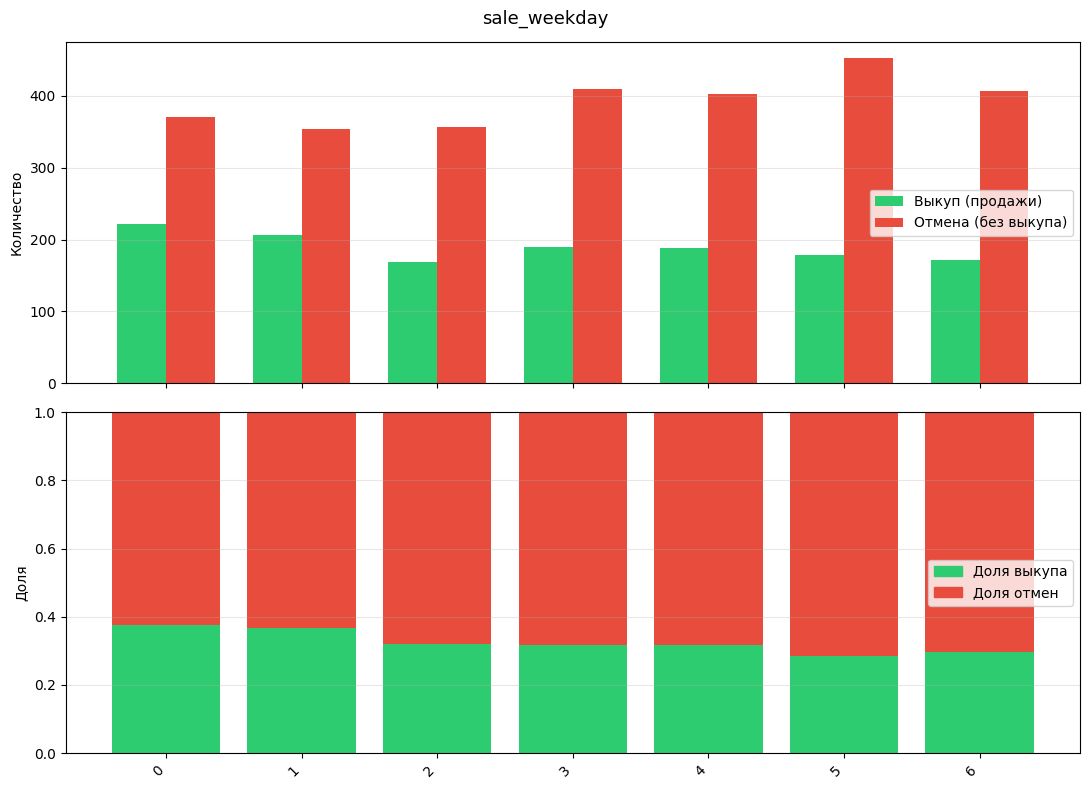


price_bin
           выкуп  без_выкупа  всего  buyout_rate
price_bin                                       
0-3k          58          67    125        0.464
3-5k         232         253    485        0.478
5-8k         444         629   1073        0.414
8-15k        391        1091   1482        0.264
15-25k       161         594    755        0.213
25k+          36         102    138        0.261


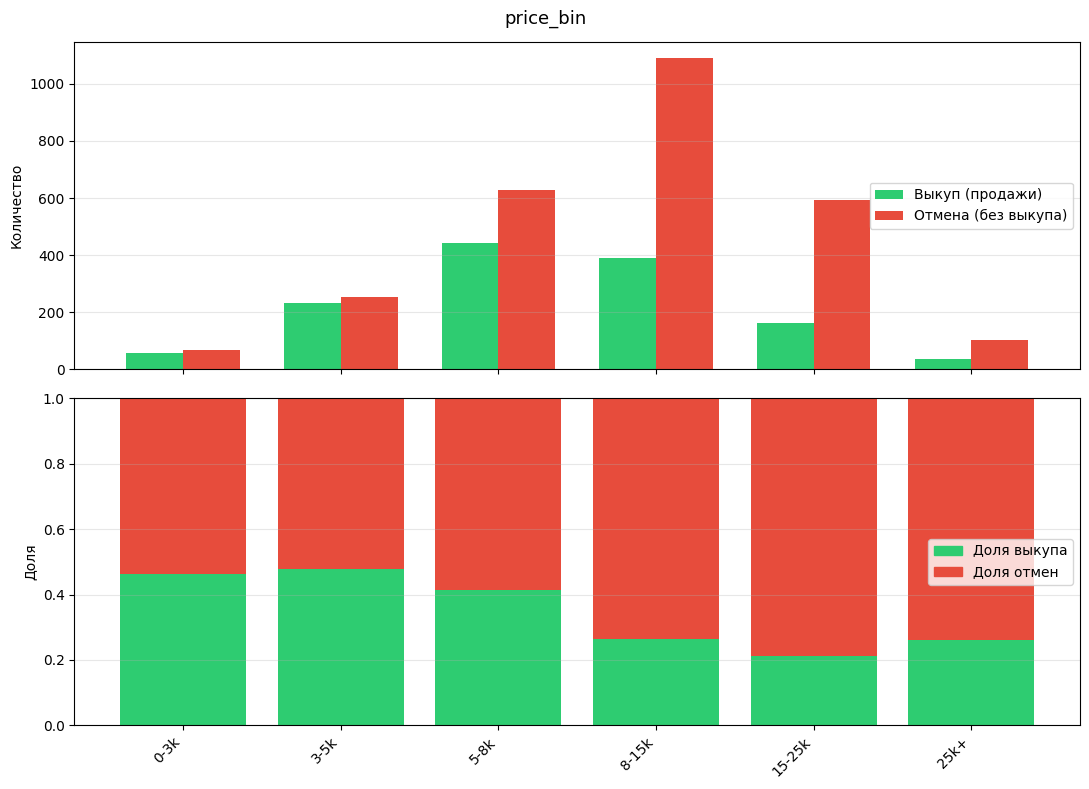


cart_bin
          выкуп  без_выкупа  всего  buyout_rate
cart_bin                                       
1-8         884        1244   2128        0.415
9-12        278         766   1044        0.266
13-16       107         432    539        0.199
17+          56         312    368        0.152


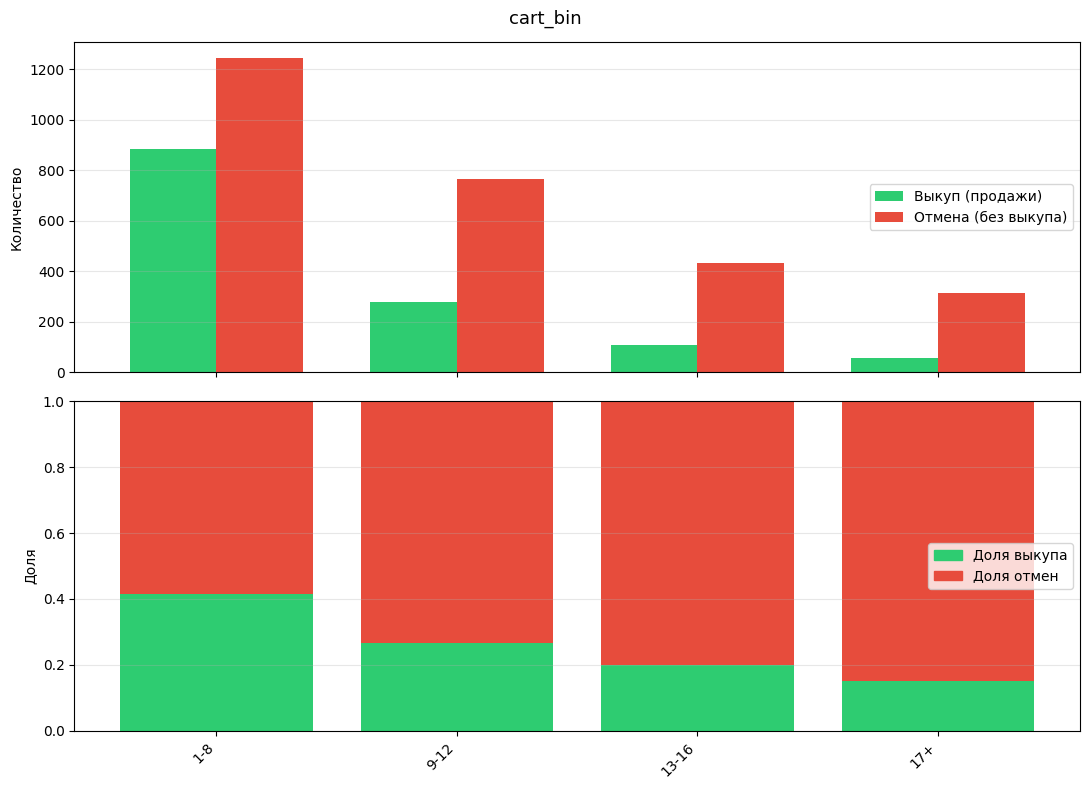


delta_bin
           выкуп  без_выкупа  всего  buyout_rate
delta_bin                                       
<30мин       496         733   1229        0.404
30-60мин     308         746   1054        0.292
1-2ч         137         469    606        0.226
>2ч          384         806   1190        0.323


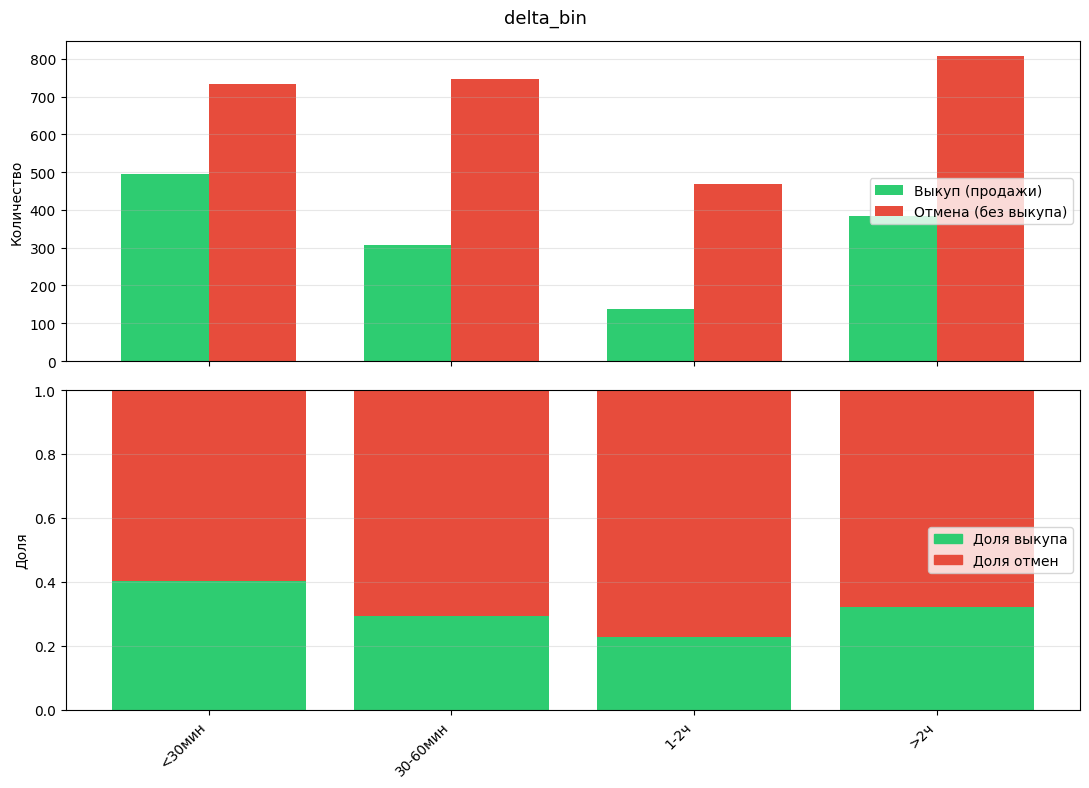


manager_bin
             выкуп  без_выкупа  всего  buyout_rate
manager_bin                                       
0-800          169         738    907        0.186
800-1.8k       255         740    995        0.256
1.8-3k         414         732   1146        0.361
3k+            487         544   1031        0.472


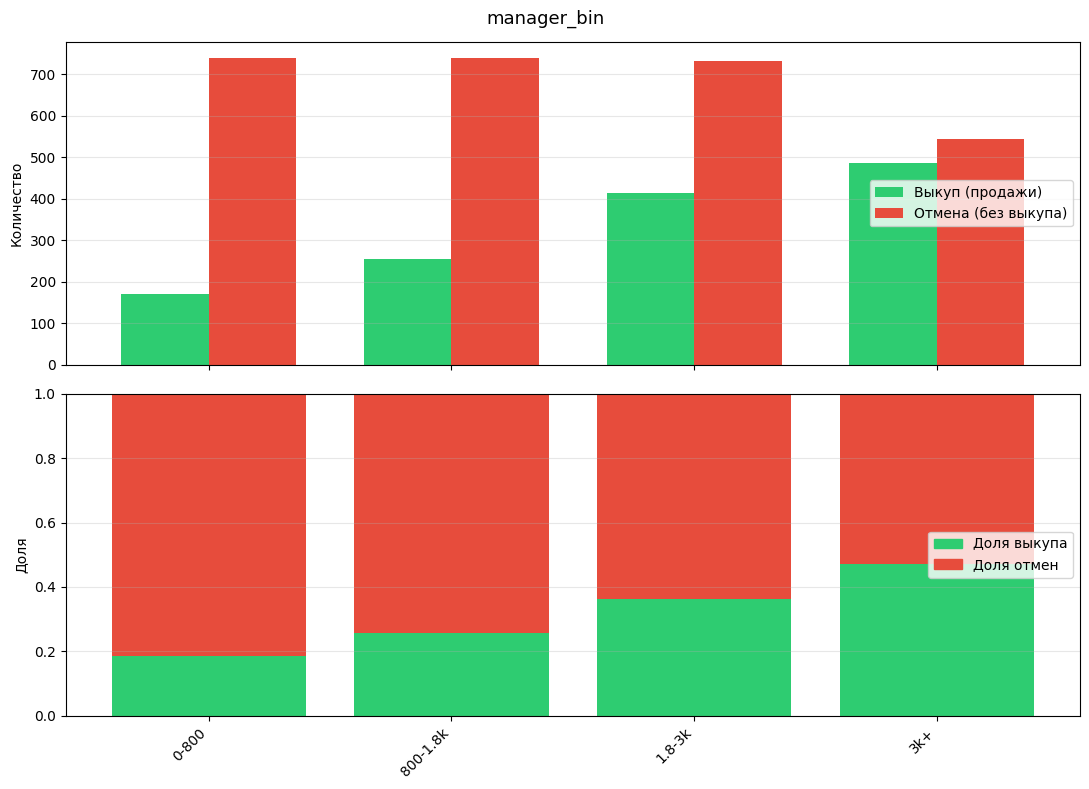


Бинарные признаки (новые клиенты)
has_discount             : 0 -> 33.8% (N= 3635), 1 -> 21.6% (N=  444)
is_paid_traffic          : 0 -> 35.5% (N= 1036), 1 -> 31.4% (N= 3043)


In [13]:
# EDA на инженерных признаках (новые клиенты)

# Категориальные бины
for col in ['sale_weekday', 'price_bin', 'cart_bin', 'delta_bin', 'manager_bin']:
    plot_feature_two_panel(df, col, col)

# Бинарные признаки — сводка
print('\n' + '=' * 60)
print('Бинарные признаки (новые клиенты)')
print('=' * 60)
for bcol in ['has_discount', 'is_paid_traffic']:
    g = df.groupby(bcol)['buyout_flag']
    rate = g.mean()
    cnt = g.count()
    print(f'{bcol:25s}: 0 -> {rate.get(0, 0):.1%} (N={cnt.get(0, 0):>5}), '
          f'1 -> {rate.get(1, 0):.1%} (N={cnt.get(1, 0):>5})')

### Наблюдения по инженерным признакам

- **`price_bin`** — buyout убывает с ценой: 0-3k = ~46%, 3-5k = ~48%, 5-8k = ~41%, 15-25k = ~21%. Нелинейная зависимость хорошо передаётся через категориальные бины.
- **`cart_bin`** — buyout монотонно убывает с числом товаров: 1-8 = ~41%, 9-12 = ~26%, 13-16 = ~18%, 17+ = ~13%. Больше товаров = выше риск отказа.
- **`delta_bin`** — время от заявки до продажи. Сигнал в первых 2 часах: <30мин = ~40%, 30-60мин = ~29%, 1-2ч = ~22%. После 2ч buyout ~30% (выборка мала и зависимость нестабильна).
- **`manager_bin`** — опытность менеджера (число сделок). Чёткий тренд: 0-800 = ~19%, 800-1.8k = ~26%, 1.8-3k = ~36%, 3k+ = ~47%. Опытные менеджеры добиваются выкупа чаще.
- **`has_discount`** — наличие скидки снижает buyout: 0 = ~34%, 1 = ~22%. Скидка даётся колеблющимся клиентам.

## 7. Определение признаков для модели

Признаки разделены на группы по типу кодирования:
- **cat_cols** (8) — one-hot encoding (low/medium cardinality)
- **num_cols** (5) — StandardScaler
- **bin_cols** (4) — без преобразования (уже 0/1)
- **geo_cols** (2) — target encoding (high cardinality geo)
- **te_cat_cols** (5) — target encoding (high cardinality categoricals)

In [14]:
cat_cols = [
    'lead_pipeline_id',
    'lead_Вид оплаты',
    'lead_Тариф Доставки',
    'lead_Квалификация лида',
    'lead_Категория и варианты выбора',
    'lead_Модель телефона',
    'price_bin',
    'sale_weekday',
    'cart_bin',
    'manager_bin',
    'delta_bin',
]

num_cols = [
    'lead_price',
    'lead_Стоимость доставки',
]

bin_cols = ['is_paid_traffic', 'has_discount']

geo_cols = ['city_clean', 'contact_region']

te_cat_cols = [
    'lead_responsible_user_id', 'lead_Проблема', 'lead_будущие покупки',
    'lead_group_id', 'lead_Служба доставки',
]

all_feature_cols = cat_cols + num_cols + bin_cols + geo_cols + te_cat_cols

print(f'cat_cols ({len(cat_cols)}): {cat_cols}')
print(f'num_cols ({len(num_cols)}): {num_cols}')
print(f'bin_cols ({len(bin_cols)}): {bin_cols}')
print(f'geo_cols ({len(geo_cols)}): {geo_cols}')
print(f'te_cat_cols ({len(te_cat_cols)}): {te_cat_cols}')
print(f'\nВсего признаков: {len(all_feature_cols)}')

# Проверяем наличие всех столбцов
missing = [c for c in all_feature_cols if c not in df.columns]
if missing:
    print(f'\nВНИМАНИЕ: отсутствуют столбцы: {missing}')
else:
    print(f'\nВсе {len(all_feature_cols)} признаков присутствуют в данных')

cat_cols (11): ['lead_pipeline_id', 'lead_Вид оплаты', 'lead_Тариф Доставки', 'lead_Квалификация лида', 'lead_Категория и варианты выбора', 'lead_Модель телефона', 'price_bin', 'sale_weekday', 'cart_bin', 'manager_bin', 'delta_bin']
num_cols (2): ['lead_price', 'lead_Стоимость доставки']
bin_cols (2): ['is_paid_traffic', 'has_discount']
geo_cols (2): ['city_clean', 'contact_region']
te_cat_cols (5): ['lead_responsible_user_id', 'lead_Проблема', 'lead_будущие покупки', 'lead_group_id', 'lead_Служба доставки']

Всего признаков: 22

Все 22 признаков присутствуют в данных


## 8. Разделение на выборки

Стратегия:
1. Разделяем весь датасет на **новых** и **повторных** клиентов
2. Внутри каждой группы — стратифицированное разбиение **60% train / 20% test / 20% val**
3. Формируем объединённые `train_df`, `test_df`, `val_df` (для модели повторных клиентов, которая обучается на всех данных)

Перед разделением применяем те же преобразования к полному датасету `df_full`.

In [15]:
# Применяем feature engineering к полному датасету
def apply_feature_engineering(d):
    """Применяет NaN-обработку, объединение категорий и создание признаков."""
    # NaN -> '__NaN__' для всех категориальных
    for col in ['lead_Квалификация лида', 'lead_Категория и варианты выбора',
                'lead_Тариф Доставки', 'lead_будущие покупки', 'lead_Модель телефона',
                'lead_Служба доставки', 'lead_Вид оплаты', 'lead_Проблема']:
        if col in d.columns:
            d[col] = d[col].fillna('__NaN__')

    # Объединение мелких категорий
    mask = d['lead_Квалификация лида'].isin(['Неквал лид', 'D - лид'])
    d.loc[mask, 'lead_Квалификация лида'] = 'D/Неквал лид'
    mask = d['lead_Категория и варианты выбора'] == 'Нет категории'
    d.loc[mask, 'lead_Категория и варианты выбора'] = '__NaN__'

    # cart_n_items -> cart_bin
    d['cart_n_items'] = d['lead_Состав заказа'].apply(count_items) if 'lead_Состав заказа' in d.columns else 0
    d['cart_bin'] = pd.cut(d['cart_n_items'], bins=CART_BINS, labels=CART_LABELS).astype(str)

    # price_bin
    d['price_bin'] = pd.cut(d['lead_price'], bins=PRICE_BINS, labels=PRICE_LABELS).astype(str)
    d.loc[d['lead_price'].isna(), 'price_bin'] = 'unknown'

    # sale_weekday
    d['sale_weekday'] = d['sale_date'].dt.dayofweek.astype(str)

    # sale_delta -> delta_bin
    d['sale_delta'] = ((d['sale_ts'] - d['lead_created_at']) / 86400).clip(lower=0).fillna(0)
    d['delta_bin'] = pd.cut(d['sale_delta'], bins=DELTA_BINS, labels=DELTA_LABELS, include_lowest=True).astype(str)

    # is_paid_traffic
    paid_channels = ['cpc', 'cpc__rt_view-yes_lead-no_all', 'Bloger', 'article_direct', 'cpm']
    d['is_paid_traffic'] = d['lead_utm_medium'].isin(paid_channels).astype(int) if 'lead_utm_medium' in d.columns else 0

    d['has_discount'] = d['lead_Скидка'].notna().astype(int)

    # lead_Стоимость доставки
    if 'lead_Стоимость доставки' in d.columns:
        d['lead_Стоимость доставки'] = d['lead_Стоимость доставки'].fillna(0)
    else:
        d['lead_Стоимость доставки'] = 0

    # ID -> строки
    for col in ['lead_pipeline_id', 'lead_group_id', 'lead_responsible_user_id']:
        if col in d.columns:
            d[col] = d[col].astype(str)

    # manager_deal_count -> manager_bin
    d['manager_deal_count'] = (
        d['lead_responsible_user_id']
        .map({str(k): v for k, v in manager_map.items()})
        .fillna(1)
    )
    d['manager_bin'] = pd.cut(d['manager_deal_count'], bins=MANAGER_BINS, labels=MANAGER_LABELS).astype(str)

    return d

# Применяем к полному датасету
apply_feature_engineering(df_full)

# Гео-матчинг для df_full
cities_full, regions_full = geo_match_series(df_full['contact_Город'])
df_full['city_clean'] = cities_full
df_full['contact_region'] = regions_full

# Разделяем на новых и повторных
is_new_full = df_full['contact_Число сделок'].isna() | (df_full['contact_Число сделок'] < 1)
df_new = df_full[is_new_full].copy()
df_ret = df_full[~is_new_full].copy()

print(f'Новые клиенты: {len(df_new)}, buyout: {df_new["buyout_flag"].mean():.4f}')
print(f'Повторные:     {len(df_ret)}, buyout: {df_ret["buyout_flag"].mean():.4f}')

# 60/20/20 внутри новых клиентов
new_train, new_temp = train_test_split(
    df_new, test_size=0.4, random_state=42, stratify=df_new['buyout_flag'])
new_val, new_test = train_test_split(
    new_temp, test_size=0.5, random_state=42, stratify=new_temp['buyout_flag'])

# 60/20/20 внутри повторных клиентов
ret_train, ret_temp = train_test_split(
    df_ret, test_size=0.4, random_state=42, stratify=df_ret['buyout_flag'])
ret_val, ret_test = train_test_split(
    ret_temp, test_size=0.5, random_state=42, stratify=ret_temp['buyout_flag'])

# Объединённые сплиты
train_df = pd.concat([new_train, ret_train], ignore_index=True)
test_df = pd.concat([new_test, ret_test], ignore_index=True)
val_df = pd.concat([new_val, ret_val], ignore_index=True)

print(f'\nНовые клиенты:')
print(f'  Train: {len(new_train)}, buyout: {new_train["buyout_flag"].mean():.4f}')
print(f'  Test:  {len(new_test)}, buyout: {new_test["buyout_flag"].mean():.4f}')
print(f'  Val:   {len(new_val)}, buyout: {new_val["buyout_flag"].mean():.4f}')

print(f'\nПовторные клиенты:')
print(f'  Train: {len(ret_train)}, buyout: {ret_train["buyout_flag"].mean():.4f}')
print(f'  Test:  {len(ret_test)}, buyout: {ret_test["buyout_flag"].mean():.4f}')
print(f'  Val:   {len(ret_val)}, buyout: {ret_val["buyout_flag"].mean():.4f}')

print(f'\nОбъединённые:')
print(f'  Train: {len(train_df)}, Test: {len(test_df)}, Val: {len(val_df)}')

Новые клиенты: 4079, buyout: 0.3248
Повторные:     13887, buyout: 0.9762

Новые клиенты:
  Train: 2447, buyout: 0.3249
  Test:  816, buyout: 0.3248
  Val:   816, buyout: 0.3248

Повторные клиенты:
  Train: 8332, buyout: 0.9762
  Test:  2778, buyout: 0.9762
  Val:   2777, buyout: 0.9762

Объединённые:
  Train: 10779, Test: 3594, Val: 3593


In [16]:
# Убираем строки с NaN в lead_price (нужен для модели новых клиентов)
for name, data in [('new_train', new_train), ('new_test', new_test), ('new_val', new_val)]:
    na_count = data['lead_price'].isna().sum()
    if na_count > 0:
        print(f'{name}: удалено {na_count} строк с NaN в lead_price')

new_train = new_train.dropna(subset=['lead_price']).copy()
new_test = new_test.dropna(subset=['lead_price']).copy()
new_val = new_val.dropna(subset=['lead_price']).copy()

# Проверяем наличие всех feature-столбцов
missing = [c for c in all_feature_cols if c not in new_train.columns]
if missing:
    print(f'ВНИМАНИЕ: отсутствуют столбцы: {missing}')
else:
    print(f'Все {len(all_feature_cols)} признаков присутствуют ✓')

print(f'\nФинальные размеры (новые клиенты):')
print(f'  Train: {len(new_train)}, Test: {len(new_test)}, Val: {len(new_val)}')

Все 22 признаков присутствуют ✓

Финальные размеры (новые клиенты):
  Train: 2447, Test: 816, Val: 816


## 9. Сохранение подготовленных данных

Сохраняем все подвыборки, списки признаков и справочник городов в единый файл `processed_data.pkl`. Ноутбук обучения (`02_model_training.ipynb`) загрузит эти данные и построит модели.

In [17]:
artifacts = {
    'new_train': new_train, 'new_test': new_test, 'new_val': new_val,
    'ret_train': ret_train, 'ret_test': ret_test, 'ret_val': ret_val,
    'train_df': train_df, 'test_df': test_df, 'val_df': val_df,
    'cat_cols': cat_cols, 'num_cols': num_cols, 'bin_cols': bin_cols,
    'geo_cols': geo_cols, 'te_cat_cols': te_cat_cols,
    'all_feature_cols': all_feature_cols,
    'russia_cities': russia_cities,
    'manager_deal_count_map': {str(k): v for k, v in manager_map.items()},
}

with open('processed_data.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

size_kb = os.path.getsize('processed_data.pkl') / 1024
print(f'Сохранено processed_data.pkl ({size_kb:.0f} KB)')
print(f'\nСодержимое:')
for key, val in artifacts.items():
    if isinstance(val, pd.DataFrame):
        print(f'  {key}: DataFrame ({len(val)} строк)')
    elif isinstance(val, list):
        print(f'  {key}: list ({len(val)} элементов)')
    elif isinstance(val, dict):
        print(f'  {key}: dict ({len(val)} элементов)')

print('\nДанные готовы для обучения → 02_model_training.ipynb')

Сохранено processed_data.pkl (63407 KB)

Содержимое:
  new_train: DataFrame (2447 строк)
  new_test: DataFrame (816 строк)
  new_val: DataFrame (816 строк)
  ret_train: DataFrame (8332 строк)
  ret_test: DataFrame (2778 строк)
  ret_val: DataFrame (2777 строк)
  train_df: DataFrame (10779 строк)
  test_df: DataFrame (3594 строк)
  val_df: DataFrame (3593 строк)
  cat_cols: list (11 элементов)
  num_cols: list (2 элементов)
  bin_cols: list (2 элементов)
  geo_cols: list (2 элементов)
  te_cat_cols: list (5 элементов)
  all_feature_cols: list (22 элементов)
  russia_cities: list (1109 элементов)
  manager_deal_count_map: dict (30 элементов)

Данные готовы для обучения → 02_model_training.ipynb
